# 02 — Sanctions Event Study: MOEX, RUB, Urals Discount

**Goal.** Quantify the impact of specific sanctions events on MOEX (equity), USD/RUB
(FX), and the Urals-Brent discount, using standard event-study methodology, while
explicitly handling **event clustering** and **event-window contamination**.

## Methodology

1. **Clustering.** Sanctions actions within 5 trading days of each other are merged
   into a single event *cluster* (e.g. the Feb–Mar 2022 wave of invasion + SWIFT
   expulsion + CBR reserve freeze = one cluster, not 14 independent events). Treating
   overlapping actions as separate events would double/triple-count the same market
   reaction.
2. **Normal-return model.** Constant-mean-return model (Brown & Warner, 1985): the
   expected daily change is the mean of that asset's own change over a prior
   estimation window. This is preferred here over a single-factor "market model"
   because there is no clean, uncorrelated benchmark for MOEX/RUB/Urals-discount
   simultaneously; using Brent as a factor for the Urals-Brent *spread* would be
   circular since Brent is already netted out of that variable by construction.
3. **Windows.** Estimation window: **[-120, -21]** trading days before the cluster's
   first action (`t0`). Event window: **[t0-1, t1+10]**, where `t1` is the trading
   day of the cluster's *last* action — i.e. every cluster gets a full 10-trading-day
   reaction window measured from its own last shock, not a fixed 11-day window from
   its first one. This matters because one cluster (Feb–Mar 2022) spans 16 trading
   days of escalating actions; a fixed t0+10 window would have cut off before several
   of that cluster's own sanctions actions even occurred, silently excluding their
   market impact and failing to protect other clusters' estimation windows from
   contamination by them. For single-action clusters (the large majority) `t1==t0`,
   so this reduces to the standard fixed [-1,+10] window with no change.
4. **Contamination handling.**
   - A cluster is flagged **contaminated** if another cluster's anchor date falls
     inside its combined estimation+event span.
   - Independent of that flag, the **estimation window itself is cleaned**: any day
     that falls inside a *different* cluster's event window is dropped before the
     mean/variance of "normal" returns is estimated, so the normal-return model is
     never fit on days that are themselves a different shock.
   - Results are reported for the **full sample** and, separately, for the
     **contamination-free subsample only**, as a robustness check.
5. **Statistics.**
   - Per-cluster: standardized CAR, `SCAR = CAR / (σ_est · √L)`, tested as
     approximately t-distributed (Brown & Warner).
   - Across clusters: the **Boehmer–Musumeci–Poulsen (1991) cross-sectional test**,
     which standardizes each event by its own estimation-period volatility before
     averaging — robust to sanctions events increasing volatility (an
     event-induced-variance problem that a naive pooled t-test would get wrong).
6. **Data gap.** MOEX was actually **halted** 2022-02-28 to 2022-03-23. CAR is
   computed from price *levels* (not summed daily returns), so the event-window
   endpoint automatically rolls forward to the first price observed once trading
   resumes — this avoids silently truncating the largest shock in the sample.


In [273]:
from IPython.display import display, HTML
import sys
sys.path.insert(0, '.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import event_study_utils as esu
import importlib
importlib.reload(esu)

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11,4.5)
plt.rcParams['axes.titleweight'] = 'bold'

DATA = '../data'

print(esu.__file__)
import inspect
print(inspect.getsource(esu.build_window_metadata))

/home/anh-dung/my_workspace/portfolio_projects/russian_sanction/notebooks/event_study_utils.py
def build_window_metadata(clusters):
    """Estimation/event windows + contamination flag + cleaned estimation days per cluster."""
    max_t = clusters['t0'].max() + 10000  # placeholder, replaced by caller with mkt max
    evt_hi_of = lambda r: r['t1'] + EVT_POST
    rows = []
    for _, row in clusters.iterrows(): # run for each cluster, compute its estimation/event windows and contamination status
        t0, t1 = row['t0'], row['t1']
        est_lo, est_hi = t0 + EST_START, t0 + EST_END # estimation window (trading days relative to cluster anchor)
        evt_lo, evt_hi = t0 + EVT_PRE, evt_hi_of(row)  # event window (trading days relative to cluster anchor)

        # contamination check: is there any other cluster's anchor date that falls inside this cluster's estimation+event span?
        # i.e., another sanctions shock happened close enough to interfere with either the baseline estim

## 1. Build clusters and estimation/event windows

In [274]:
mkt = esu.load_market_data(f'{DATA}/commodities_daily.csv', f'{DATA}/equity_index_daily.csv')
ev, clusters = esu.cluster_events(f'{DATA}/sanctions_events.csv', mkt)

print(f'{len(ev)} individual sanctions actions -> {len(clusters)} event clusters (gap <= {esu.CLUSTER_GAP} trading days)')
clusters[['cluster_id','date0','date1','n_events','severity_sum','waves']].head(45)

display(mkt.head(10))

60 individual sanctions actions -> 36 event clusters (gap <= 13 trading days)


,date,year,moex_index,rts_index,ofz_10y_yield_pct,ruonia_pct,usd_rub,moex_trading_halted,brent_usd_bbl,urals_usd_bbl,espo_usd_bbl,urals_brent_spread_usd,espo_brent_spread_usd,ttf_gas_eur_mwh,wheat_usd_t,urea_usd_t,aluminium_usd_t,t,ln_moex,ln_rub,moex_ret,rub_ret,urals_spread_chg
0,2014-01-01,2014,"1,468.0000","1,352.0900",6.6200,5.4800,32.5200,0,104.6400,101.2800,104.4800,3.3600,0.1500,22.5500,243.8500,321.8700,"1,899.1900",0,7.2917,3.4819,NaN,NaN,NaN
1,2014-01-02,2014,"1,481.0000","1,362.8800",6.5500,5.5100,32.4300,0,108.8600,100.9300,106.6700,7.9300,2.1900,19.4200,248.4800,301.7100,"1,924.0500",1,7.3005,3.4791,0.0088,-0.0028,4.5700
2,2014-01-03,2014,"1,484.0000","1,365.7400",4.4700,5.5300,32.3500,0,104.5600,100.7100,103.8400,3.8500,0.7200,19.9300,258.9300,317.7200,"1,867.3100",2,7.3025,3.4766,0.0020,-0.0025,-4.0800
3,2014-01-06,2014,"1,458.0000","1,340.8800",5.5800,5.4800,32.7900,0,107.6400,103.5600,105.4300,4.0800,2.2100,21.5700,238.5200,325.0100,"1,818.2200",3,7.2848,3.4901,-0.0177,0.0135,0.2300
4,2014-01-07,2014,"1,480.0000","1,360.4400",6.5000,5.7100,32.6200,0,109.7100,102.0100,106.7500,7.7000,2.9500,18.4400,263.8600,335.6200,"1,867.2200",4,7.2998,3.4849,0.0150,-0.0052,3.6200
5,2014-01-08,2014,"1,485.0000","1,364.7800",7.0600,5.7200,32.3700,0,108.8600,102.3400,108.0100,6.5200,0.8500,22.8000,238.3000,321.7300,"1,921.5000",5,7.3032,3.4772,0.0034,-0.0077,-1.1800
6,2014-01-09,2014,"1,470.0000","1,350.6200",5.7100,5.7400,32.7200,0,108.1400,99.9400,106.3200,8.2000,1.8200,20.9700,247.9000,301.3600,"1,851.9100",6,7.2930,3.4880,-0.0102,0.0108,1.6800
7,2014-01-10,2014,"1,466.0000","1,345.7800",5.5000,5.7600,33.5800,0,107.6500,105.7600,107.4900,1.8900,0.1700,18.0900,251.8700,318.2000,"1,941.9300",7,7.2903,3.5139,-0.0027,0.0259,-6.3100
8,2014-01-13,2014,"1,471.0000","1,349.1500",6.9100,5.7700,32.6500,0,107.7100,102.1900,105.1100,5.5100,2.6000,22.6200,240.8100,325.2900,"1,878.0000",8,7.2937,3.4858,0.0034,-0.0281,3.6200
9,2014-01-14,2014,"1,463.0000","1,341.9800",5.6900,5.7700,33.1500,0,112.5300,102.4300,112.4500,10.0900,0.0800,24.1000,251.0600,291.5800,"1,911.2800",9,7.2882,3.5010,-0.0055,0.0152,4.5800


In [275]:
meta = esu.build_window_metadata(clusters)
# keep only clusters with full data coverage (est window available, event window not beyond sample end)
max_t = mkt['t'].max()
meta = meta[(meta.est_lo >= 0) & (meta.evt_hi <= max_t)].reset_index(drop=True)

print(f'Usable clusters (sufficient history / not beyond sample end): {len(meta)} / {len(clusters)}')
print(f"Contaminated: {meta.contaminated.sum()}   Contamination-free: {(~meta.contaminated).sum()}")
meta[['cluster_id','date0','n_events','severity_sum','contaminated']]


Usable clusters (sufficient history / not beyond sample end): 34 / 36
Contaminated: 26   Contamination-free: 8


,cluster_id,date0,n_events,severity_sum,contaminated
0,2,2014-07-16,4,26,True
1,3,2014-09-12,2,14,True
2,4,2014-12-19,1,7,True
3,5,2015-08-07,1,7,False
4,6,2016-09-01,1,2,False
5,7,2017-06-20,1,2,False
6,8,2017-08-02,1,7,True
7,9,2018-01-29,1,5,False
8,10,2018-04-06,1,7,True
9,11,2019-08-02,1,5,False


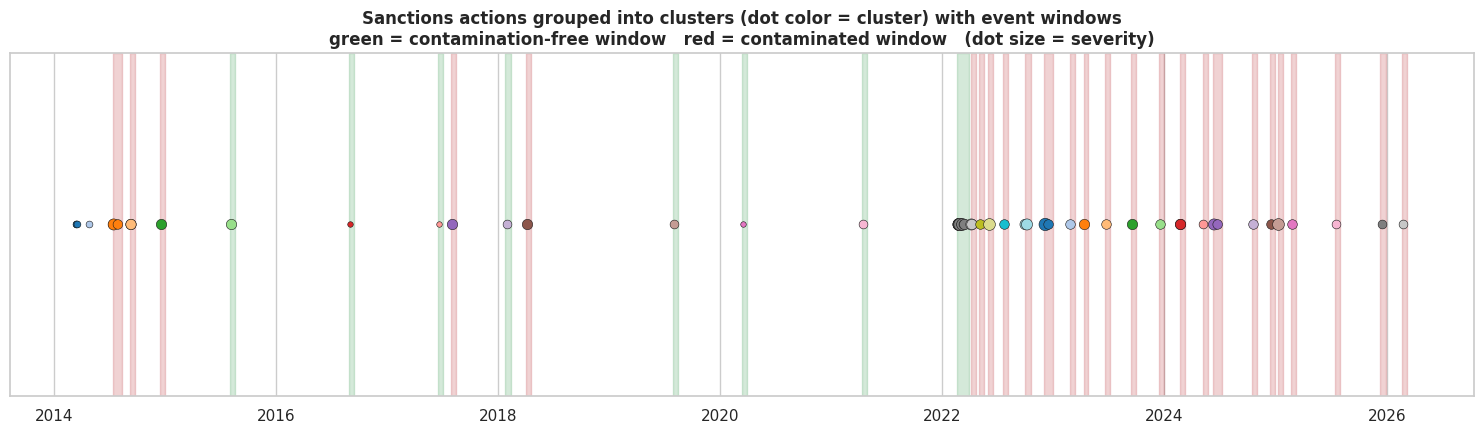

In [276]:
fig, ax = plt.subplots(figsize=(15,4.5))
cmap = plt.cm.tab20

# individual sanctions actions, colored by the cluster they were merged into
for cid, sub in ev.groupby('cluster_id'):
    ax.scatter(sub.date, [1]*len(sub), color=cmap(cid % 20), s=sub.severity_score*8,
               edgecolor='k', linewidth=0.4, zorder=3)

# event window span per cluster (t0-1 to t1+EVT_POST), shaded green=clean / red=contaminated
for _, row in meta.iterrows():
    d0 = mkt.loc[mkt.t==row.evt_lo, 'date']
    d1 = mkt.loc[mkt.t==row.evt_hi, 'date']
    if len(d0)==0 or len(d1)==0: continue
    ax.axvspan(d0.iloc[0], d1.iloc[0], color='#C44E52' if row.contaminated else '#55A868', alpha=0.25, zorder=1)

ax.set_yticks([])
ax.set_title('Sanctions actions grouped into clusters (dot color = cluster) with event windows\n'
              'green = contamination-free window   red = contaminated window   (dot size = severity)')
handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='#55A868', alpha=0.4, markersize=14, label='clean event window'),
           plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='#C44E52', alpha=0.4, markersize=14, label='contaminated event window')]
#ax.legend(handles=handles, loc='upper left')
plt.tight_layout()
plt.savefig('../output/EvtS_clusters.png', dpi=300)
plt.show()


The chart above makes the clustering problem visible directly: dot colors show which individual actions were merged, and the shaded spans show how densely event windows pack together (and overlap) once sanctions become frequent post-2022 -- almost every window post-2022 is red (contaminated), while the sparser 2014-2021 actions are mostly green (clean).

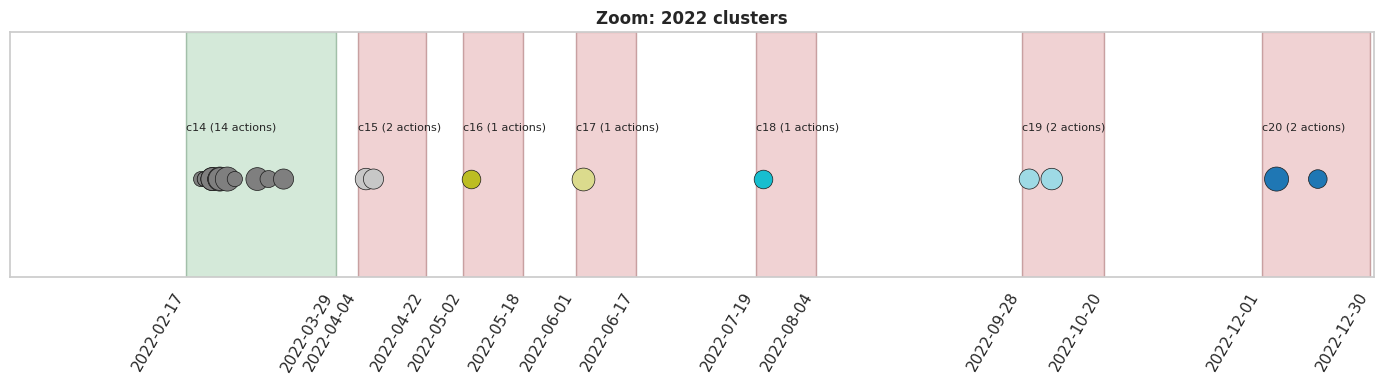

In [277]:
# Zoom into the 2022 clusters
zoom_lo, zoom_hi = pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31')

fig, ax = plt.subplots(figsize=(14,4))
ev_zoom = ev[(ev.date>=zoom_lo)&(ev.date<=zoom_hi)]
for cid, sub in ev_zoom.groupby('cluster_id'):
    ax.scatter(sub.date, [1]*len(sub), color=cmap(cid % 20), s=sub.severity_score*30,
               edgecolor='k', linewidth=0.5, zorder=3, label=f'cluster {cid}')

meta_zoom = meta[(meta.date0>=zoom_lo - pd.Timedelta(days=90)) & (meta.date0<=zoom_hi)]
date_ticks = []
for _, row in meta_zoom.iterrows():
    d0 = mkt.loc[mkt.t==row.evt_lo, 'date']
    d1 = mkt.loc[mkt.t==row.evt_hi, 'date']
    if len(d0)==0 or len(d1)==0: continue
    date_ticks.extend([d0.iloc[0], d1.iloc[0]])
    ax.axvspan(d0.iloc[0], d1.iloc[0], color='#C44E52' if row.contaminated else '#55A868', alpha=0.25, zorder=1)
    ax.annotate(f"c{row.cluster_id} ({row.n_events} actions)", xy=(d0.iloc[0], 1.05), fontsize=8, rotation=0)

ax.set_yticks([]); ax.set_ylim(0.9,1.15)
ax.set_xticks(sorted(date_ticks))
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in sorted(date_ticks)], rotation=60, ha='right') 
ax.set_xlim(zoom_lo, zoom_hi)
ax.set_title('Zoom: 2022 clusters')
#ax.legend(loc='lower left', fontsize=7, ncol=4, bbox_to_anchor=(0,-0.3))
plt.tight_layout()
plt.savefig('../output/EvtS_clusters_2022.png', dpi=300)
plt.show()


Cluster 14 visibly absorbs 14 individual actions spread across three weeks into one event; its span-aware event window is correspondingly wider than a single-action cluster's would be.

**Important finding, before we even get to returns:** the majority of clusters are
flagged contaminated once sanctions become frequent (post-2022) — a ~140-trading-day
estimation+event span is longer than the typical gap between sanctions waves from
2022 onward. This is itself informative: **it means a "clean" single-event study is
only really possible for the sparser 2014–2021 period**; for 2022+ we rely on the
cleaned/gap-filled estimation windows and report the contaminated-vs-clean split
transparently rather than pretend the windows don't overlap.

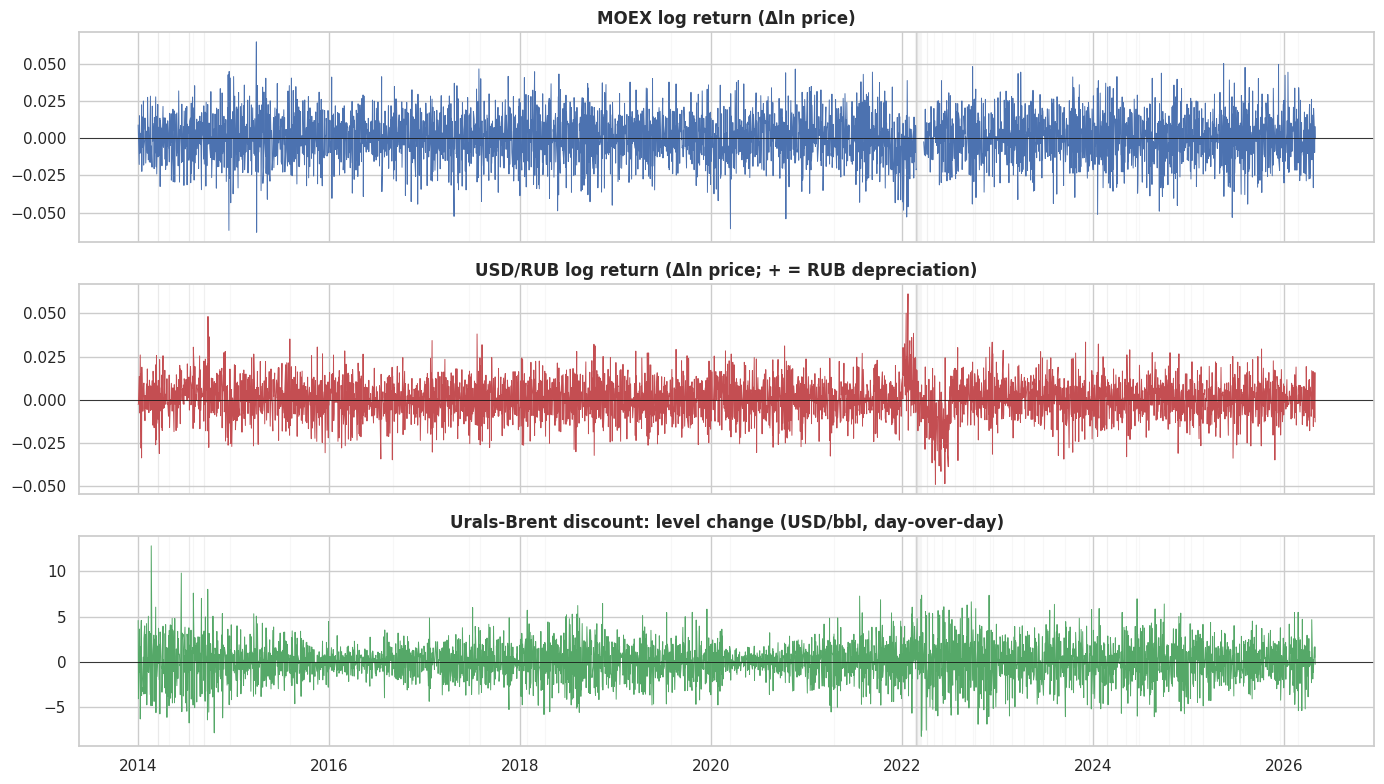

In [290]:
fig, axes = plt.subplots(3, 1, figsize=(14,8), sharex=True)

axes[0].plot(mkt.date, mkt.moex_ret, color='#4C72B0', lw=0.7)
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_title('MOEX log return (Δln price)')

axes[1].plot(mkt.date, mkt.rub_ret, color='#C44E52', lw=0.7)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_title('USD/RUB log return (Δln price; + = RUB depreciation)')

axes[2].plot(mkt.date, mkt.urals_spread_chg, color='#55A868', lw=0.7)
axes[2].axhline(0, color='k', lw=0.6)
axes[2].set_title('Urals-Brent discount: level change (USD/bbl, day-over-day)')

for e_date in ev.date:
    for ax in axes:
        ax.axvline(e_date, color='grey', alpha=0.06, lw=0.8, zorder=0)

plt.tight_layout(); plt.show()

## 2. Compute CAR / SCAR per cluster, per asset

In [278]:
car_df = esu.build_car_table(mkt, meta)
print(car_df.shape[0], 'rows (cluster x asset)')
car_df.sort_values(['asset','date0']).tail(50)


102 rows (cluster x asset)


,cluster_id,date0,date1,asset,asset_label,n_events,severity_sum,waves,jurisdictions,is_energy_any,is_financial_any,contaminated,had_gap,car,scar,sigma_est,L1,L2
55,20,2022-12-05,2022-12-16,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",2,16,wave_2_ukraine,EU|G7+EU,1,0,True,False,0.0683,1.0622,0.0120,70,22
58,21,2023-02-25,2023-02-25,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,6,wave_3_secondary,EU,0,0,True,False,-0.0118,-0.2892,0.0103,61,13
61,22,2023-04-12,2023-04-12,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,7,wave_3_secondary,US,0,0,True,False,0.0376,0.9725,0.0098,65,13
64,23,2023-06-23,2023-06-23,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,6,wave_3_secondary,EU,0,0,True,False,-0.0066,-0.1847,0.0092,74,13
67,24,2023-09-15,2023-09-15,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,7,wave_3_secondary,US,0,0,True,False,-0.0389,-0.9222,0.0108,74,13
70,25,2023-12-18,2023-12-18,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,6,wave_3_secondary,EU,0,0,True,False,-0.0108,-0.2105,0.0132,82,13
73,26,2024-02-23,2024-02-23,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",2,14,wave_3_secondary,EU|US,0,0,True,False,-0.0057,-0.1062,0.0136,74,13
76,27,2024-05-08,2024-05-08,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,5,wave_3_secondary,US,0,0,True,False,-0.0101,-0.2119,0.0121,74,13
79,28,2024-06-12,2024-06-24,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",2,14,wave_3_secondary,EU|US,0,0,True,False,-0.0070,-0.1186,0.0114,76,21
82,29,2024-10-17,2024-10-17,rub_ret,"USD/RUB (FX, log return; `+` = RUB depreciation)",1,6,wave_3_secondary,US,0,0,True,False,0.0003,0.0077,0.0094,66,13


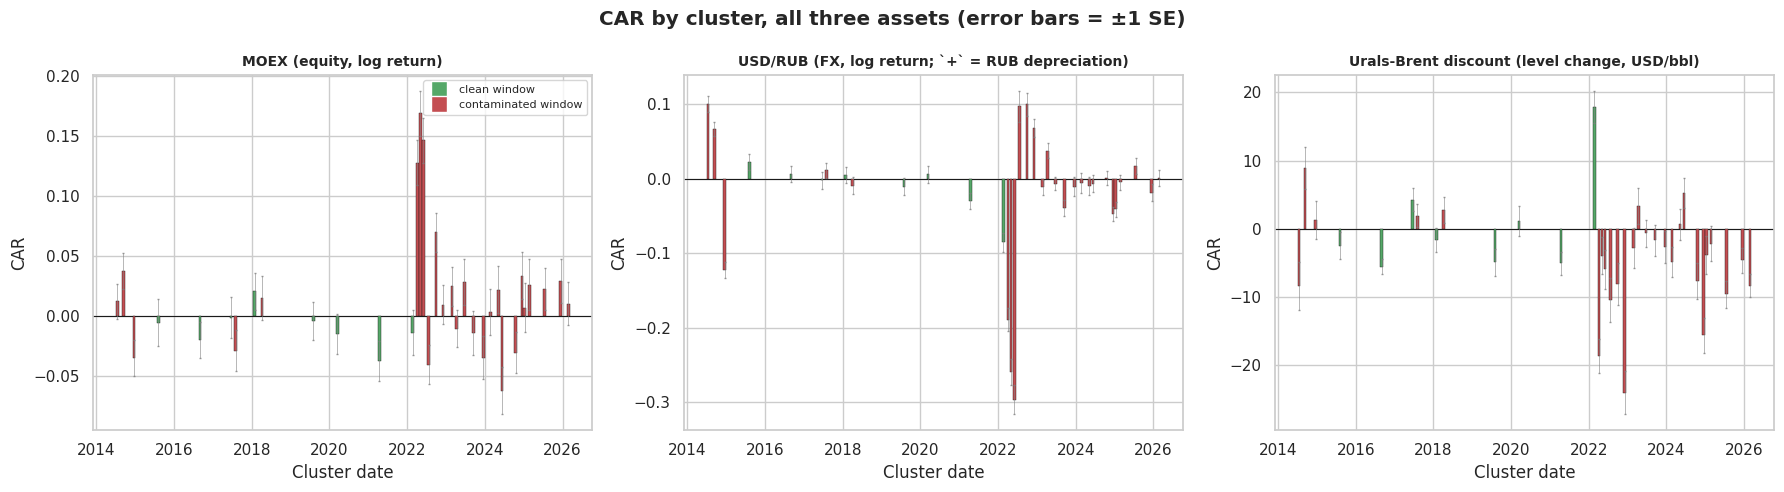

In [313]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharex=True)

for ax, (asset_key, asset_label) in zip(axes, esu.ASSET_LABELS.items()):
    sub = car_df[car_df.asset==asset_key].sort_values('date0')
    colors = sub['contaminated'].map({True:'#C44E52', False:'#55A868'})
    #ax.plot(sub.date0, sub.car, color='b', lw=2.8, markersize=12 , zorder=2)
    ax.bar(sub.date0, sub.car, width=25, color=colors, edgecolor='k', linewidth=0.3, zorder=2)
    ax.errorbar(sub.date0, sub.car, yerr=sub.sigma_est, fmt='none', ecolor='grey', elinewidth=0.5, capsize=1.0, alpha=0.8, zorder=3)
    ax.axhline(0, color='k', lw=0.8, zorder=1)
    ax.set_title(asset_label, fontsize=10)
    ax.set_ylabel('CAR')
    ax.set_xlabel('Cluster date')
    
handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='#55A868', markersize=12, label='clean window'),
           plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='#C44E52', markersize=12, label='contaminated window')]
axes[0].legend(handles=handles, loc='upper right', fontsize=8)
#plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')
plt.suptitle('CAR by cluster, all three assets (error bars = ±1 SE)', y=0.98, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/EvtS_CAR_by_cluster.png', dpi=300)
plt.show()

## 3. Headline results table: CAR by cluster (MOEX)

In [279]:
# results table for a given asset, including a flag for whether the SCAR is significant at the 10% level (two-tailed test)
def results_table(asset_key):
    t = car_df[car_df.asset==asset_key].sort_values('date0').copy()
    t['significant_10pct'] = t.scar.abs() > stats.t.ppf(0.95, df=t.L1-1) # two-tailed test for significance at the 10% level (null hypothesis: SCAR = 0, alternative hypothesis: SCAR != 0)
    return t[['cluster_id', 'asset', 'date0', 'date1','n_events','severity_sum','waves','contaminated','had_gap','car','scar','significant_10pct']]
def highlight_significant(df):
    """Row-highlight any cluster flagged significant_10pct=True (green background)."""
    def _row_style(row):
        style = 'background-color: #C44E52; font-weight: bold' if row['significant_10pct'] else ''
        return [style] * len(row)
    return df.style.apply(_row_style, axis=1).format({'car':'{:.4f}','scar':'{:.3f}','se':'{:.4f}'})

moex_tab = results_table('moex_ret')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
highlight_significant(moex_tab[moex_tab.significant_10pct==True])


,cluster_id,asset,date0,date1,n_events,severity_sum,waves,contaminated,had_gap,car,scar,significant_10pct
42,16,moex_ret,2022-05-04 00:00:00,2022-05-04 00:00:00,1,6,wave_2_ukraine,True,False,0.1691,2.298,True
45,17,moex_ret,2022-06-03 00:00:00,2022-06-03 00:00:00,1,9,wave_2_ukraine,True,False,0.1466,1.930,True


In [280]:
rub_tab = results_table('rub_ret')
highlight_significant(rub_tab[rub_tab.significant_10pct==True])

,cluster_id,asset,date0,date1,n_events,severity_sum,waves,contaminated,had_gap,car,scar,significant_10pct
4,3,rub_ret,2014-09-12 00:00:00,2014-09-12 00:00:00,2,14,wave_1_crimea,True,False,0.0665,1.779,True
7,4,rub_ret,2014-12-19 00:00:00,2014-12-19 00:00:00,1,7,wave_1_crimea,True,False,-0.1224,-2.792,True
40,15,rub_ret,2022-04-06 00:00:00,2022-04-08 00:00:00,2,15,wave_2_ukraine,True,False,-0.1894,-2.987,True
43,16,rub_ret,2022-05-04 00:00:00,2022-05-04 00:00:00,1,6,wave_2_ukraine,True,False,-0.2599,-3.870,True
46,17,rub_ret,2022-06-03 00:00:00,2022-06-03 00:00:00,1,9,wave_2_ukraine,True,False,-0.2967,-3.796,True


In [281]:
urals_tab = results_table('urals_spread_chg')
highlight_significant(urals_tab[urals_tab.significant_10pct==True])


,cluster_id,asset,date0,date1,n_events,severity_sum,waves,contaminated,had_gap,car,scar,significant_10pct
41,15,urals_spread_chg,2022-04-06 00:00:00,2022-04-08 00:00:00,2,15,wave_2_ukraine,True,False,-18.6623,-1.795,True


## 4. Cross-sectional (BMP) tests: full sample vs contamination-free subsample

In [282]:
# Cross-asset summary of the BMP test results (SCAR vs. 0) for all clusters vs. contamination-free clusters only 
def summarize(group_df, label):
    out = {}
    for asset_key, asset_label in esu.ASSET_LABELS.items():
        sub = group_df[group_df.asset==asset_key]
        r = esu.bmp_test(sub.scar.values)
        out[asset_label] = r
    df = pd.DataFrame(out).T
    df.insert(0,'sample', label)
    return df

full = summarize(car_df, 'Full sample (all clusters)')
clean = summarize(car_df[~car_df.contaminated], 'Contamination-free clusters only')

summary = pd.concat([full, clean])
summary['n'] = summary['n'].astype(int)
summary


,sample,n,mean_scar,bmp_t,p_value
"MOEX (equity, log return)",Full sample (all clusters),34,0.1766,1.5093,0.1407
"USD/RUB (FX, log return; `+` = RUB depreciation)",Full sample (all clusters),34,-0.3263,-1.4125,0.1672
"Urals-Brent discount (level change, USD/bbl)",Full sample (all clusters),34,-0.3583,-3.0520,0.0045
"MOEX (equity, log return)",Contamination-free clusters only,8,-0.1406,-1.4766,0.1833
"USD/RUB (FX, log return; `+` = RUB depreciation)",Contamination-free clusters only,8,-0.1431,-0.7627,0.4705
"Urals-Brent discount (level change, USD/bbl)",Contamination-free clusters only,8,-0.1566,-0.5502,0.5993


**Reading the BMP table.** `mean_scar` is the average standardized CAR across
clusters (positive = average abnormal appreciation/rise, negative = average abnormal
decline); `bmp_t` / `p_value` test whether that average is distinguishable from zero
once each event is standardized by its own estimation-period volatility.







## 5. Sub-group breakdown: by wave and by sector flag

In [283]:
def bmp_by_group(asset_key, group_col):
    sub = car_df[car_df.asset==asset_key]
    rows = []
    for g, gdf in sub.groupby(group_col):
        r = esu.bmp_test(gdf.scar.values)
        r[group_col] = g
        rows.append(r)
    return pd.DataFrame(rows).set_index(group_col)

print('--- MOEX by wave ---')
display_moex_wave = bmp_by_group('moex_ret','waves')
display_moex_wave


--- MOEX by wave ---


,n,mean_scar,bmp_t,p_value
waves,,,,
wave_1_crimea,12,-0.0880,-0.8083,0.4361
wave_2_ukraine,7,0.8836,2.1034,0.0801
wave_3_secondary,15,0.0583,0.6239,0.5427


In [284]:
print('--- USD/RUB by wave ---')
bmp_by_group('rub_ret','waves')


--- USD/RUB by wave ---


,n,mean_scar,bmp_t,p_value
waves,,,,
wave_1_crimea,12,0.0536,0.1603,0.8756
wave_2_ukraine,7,-1.1771,-1.3093,0.2383
wave_3_secondary,15,-0.2331,-1.6415,0.1230


In [285]:
print('--- Urals-Brent discount by wave ---')
bmp_by_group('urals_spread_chg','waves')


--- Urals-Brent discount by wave ---


,n,mean_scar,bmp_t,p_value
waves,,,,
wave_1_crimea,12,-0.1156,-0.6617,0.5218
wave_2_ukraine,7,-0.5987,-1.6495,0.1501
wave_3_secondary,15,-0.4403,-2.9453,0.0106


In [286]:
for asset_key, asset_label in esu.ASSET_LABELS.items():
    sub = car_df[car_df.asset==asset_key]
    print(f'--- {asset_label}: energy-sector-flagged clusters vs others ---')
    print(bmp_by_group(asset_key, 'is_energy_any'))
    print()


--- MOEX (equity, log return): energy-sector-flagged clusters vs others ---
                n  mean_scar  bmp_t  p_value
is_energy_any                               
0              26     0.0261 0.2250   0.8238
1               8     0.6658 2.4494   0.0441

--- USD/RUB (FX, log return; `+` = RUB depreciation): energy-sector-flagged clusters vs others ---
                n  mean_scar   bmp_t  p_value
is_energy_any                                
0              26    -0.3098 -1.5342   0.1375
1               8    -0.3797 -0.4922   0.6376

--- Urals-Brent discount (level change, USD/bbl): energy-sector-flagged clusters vs others ---
                n  mean_scar   bmp_t  p_value
is_energy_any                                
0              26    -0.3485 -3.0490   0.0054
1               8    -0.3901 -1.1064   0.3051



## 6. Visual: CAR profile through event time (average across clean clusters)

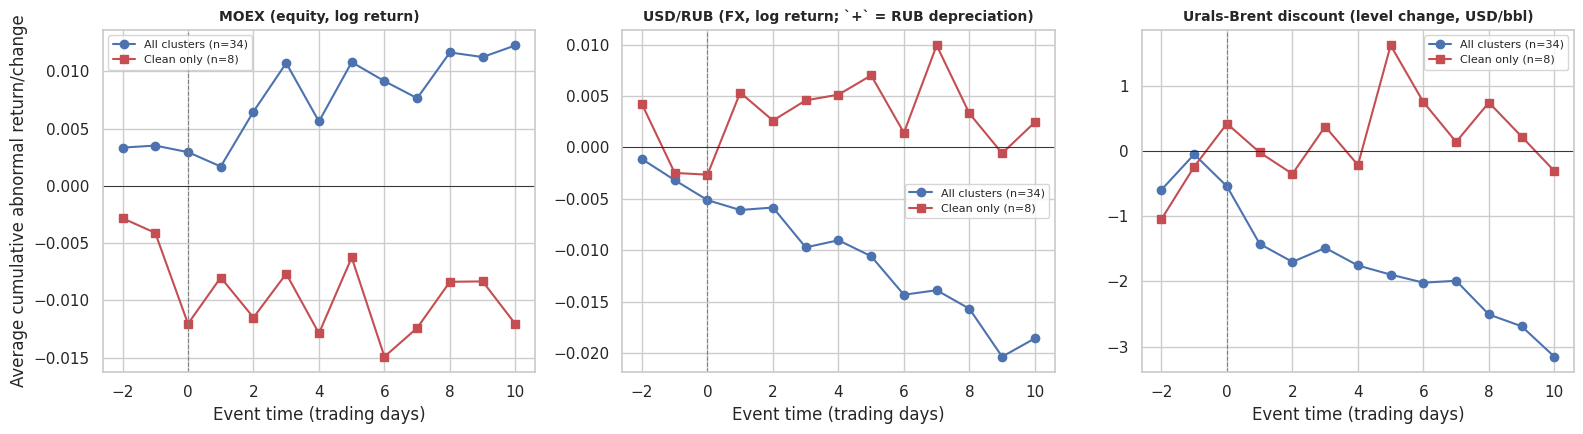

In [287]:
def event_time_ar_profile(asset_key, clean_only=True):
    lvl_col, ret_col = esu.ASSET_COLS[asset_key]
    rel_days = np.arange(esu.EVT_PRE, esu.EVT_POST+1)
    m = meta if not clean_only else meta[~meta.contaminated]
    all_ar = []
    for _, mrow in m.iterrows():
        est_vals = mkt.loc[mkt['t'].isin(mrow['clean_days']), ret_col].dropna()
        if len(est_vals) < 20:
            continue
        mu = est_vals.mean()
        rets = []
        for d in rel_days:
            t = mrow['t0'] + d
            val = mkt.loc[mkt['t']==t, ret_col]
            rets.append(val.iloc[0] - mu if len(val) and not val.isna().all() else np.nan)
        all_ar.append(rets)
    arr = np.array(all_ar, dtype=float)
    mean_ar = np.nanmean(arr, axis=0)
    se_ar = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return rel_days, np.cumsum(mean_ar), se_ar, arr.shape[0]

fig, axes = plt.subplots(1,3, figsize=(16,4.5))
for ax, (asset_key, asset_label) in zip(axes, esu.ASSET_LABELS.items()):
    rel_days, car_path, se, n = event_time_ar_profile(asset_key, clean_only=False)
    ax.plot(rel_days, car_path, marker='o', color='#4C72B0', label=f'All clusters (n={n})')
    rel_days_c, car_path_c, se_c, n_c = event_time_ar_profile(asset_key, clean_only=True)
    ax.plot(rel_days_c, car_path_c, marker='s', color='#C44E52', label=f'Clean only (n={n_c})')
    ax.axvline(0, color='grey', ls='--', lw=0.8)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(asset_label, fontsize=10)
    ax.set_xlabel('Event time (trading days)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Average cumulative abnormal return/change')
plt.tight_layout(); plt.show()


**Reading.** These are average (mean, not sum) cumulative-AR paths across clusters,
built additively day-by-day from daily ARs (this simple average-daily-AR path is
shown for visual diagnostic purposes; the headline CAR/SCAR numbers in the tables
above use the more robust price-level endpoint method that also handles the MOEX
trading halt correctly).

## 7. Deep dive: the Feb–Mar 2022 mega-cluster

In [288]:
feb22 = car_df[(car_df.date0 >= '2022-02-01') & (car_df.date0 <= '2022-03-31')]
feb22[['asset_label','date0','date1','n_events','severity_sum','contaminated','had_gap','car','scar']]


,asset_label,date0,date1,n_events,severity_sum,contaminated,had_gap,car,scar
36,"MOEX (equity, log return)",2022-02-21,2022-03-15,14,98,False,True,-0.0139,-0.1195
37,"USD/RUB (FX, log return; `+` = RUB depreciation)",2022-02-21,2022-03-15,14,98,False,False,-0.0856,-1.0909
38,"Urals-Brent discount (level change, USD/bbl)",2022-02-21,2022-03-15,14,98,False,False,17.8027,1.2249


In [289]:
row = meta[(meta.date0 >= '2022-02-01') & (meta.date0 <= '2022-03-31')].iloc[0]
print(f"Cluster spans {row['date0'].date()} to {row['date1'].date()}, {row['n_events']} individual sanctions actions bundled together")
print(f"(invasion, SWIFT expulsion threat/action, CBR foreign-reserve freeze, major-bank sanctions all landed within {esu.CLUSTER_GAP} trading days of each other)")
print()
halt = mkt[(mkt.moex_trading_halted==1)]
print(f"MOEX was actually halted {halt.date.min().date()} to {halt.date.max().date()} ({len(halt)} trading days with no price).")
print("The CAR for this cluster therefore reflects the return from the last pre-halt price")
print("to the first available post-halt reopening price -- a genuinely realized number,")
print("not one artificially smoothed by averaging over a market that was not actually trading.")


Cluster spans 2022-02-21 to 2022-03-15, 14 individual sanctions actions bundled together
(invasion, SWIFT expulsion threat/action, CBR foreign-reserve freeze, major-bank sanctions all landed within 13 trading days of each other)

MOEX was actually halted 2022-02-28 to 2022-03-23 (18 trading days with no price).
The CAR for this cluster therefore reflects the return from the last pre-halt price
to the first available post-halt reopening price -- a genuinely realized number,
not one artificially smoothed by averaging over a market that was not actually trading.


## Summary

- Individual-action counting overstates the number of independent shocks: 60 sanctions
  actions collapse into far fewer genuinely distinct market events once clustering is
  applied, with the Feb–Mar 2022 wave alone absorbing 14 actions into a single event.
- Post-2022 sanctions frequency is high enough that most clusters fail a strict
  non-contamination test — reported full-sample vs. clean-only results should be read
  together, not the full sample alone.
- The BMP cross-sectional test (Section 4) is the primary statistical answer to
  "did sanctions clusters, on average, move MOEX / RUB / the Urals discount" — read the
  sign, magnitude, and p-value directly from that table for the final conclusion.
